# HỆ THỐNG NHẬN DẠNG BỆNH LÁ CÂY
## MobileNetV2 + KNN & SVM
---

## 1. Import thư viện

In [1]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.preprocessing import StandardScaler
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Cấu hình

In [2]:
# Config
TRAIN_DIR = "archive/PlantVillage/train"
VAL_DIR = "archive/PlantVillage/val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_STATE = 42

os.makedirs("models", exist_ok=True)

# BẮT ĐẦU ĐO THỜI GIAN TỔNG
TOTAL_START = time.time()

## 3. Load Dataset

In [3]:
print("\nLoading dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE
)

class_names = train_ds.class_names

# Chuẩn hóa [0, 1]
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

print(f"Số lượng classes: {len(class_names)}")
print(f"Classes: {class_names[:5]}...")


Loading dataset...
Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Số lượng classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...


## 4. Xây dựng Feature Extractor (MobileNetV2)

In [4]:
print("\nBuilding MobileNetV2...")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

print(f"Feature size: {extractor.output_shape[1]}")


Building MobileNetV2...
Feature size: 1280


## 5. Trích xuất Features (ĐO THỜI GIAN)

In [5]:
print("\nExtracting features...")

FEATURE_START = time.time()

# Extract train features
X_train, y_train = [], []
for images, labels in train_ds:
    features = extractor(images, training=False).numpy()
    X_train.append(features)
    y_train.append(labels.numpy())
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

# Extract val features
X_val, y_val = [], []
for images, labels in val_ds:
    features = extractor(images, training=False).numpy()
    X_val.append(features)
    y_val.append(labels.numpy())
X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

FEATURE_TIME = time.time() - FEATURE_START

print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"\nFeature extraction time: {FEATURE_TIME:.2f}s ({FEATURE_TIME/60:.2f} phút)")


Extracting features...
Train shape: (43444, 1280)
Val shape: (10861, 1280)

Feature extraction time: 957.80s (15.96 phút)


## 6. Kiểm tra Models có sẵn

In [6]:
models_exist = (
    os.path.exists("models/scaler.joblib") and 
    os.path.exists("models/knn_model.joblib") and 
    os.path.exists("models/svm_model.joblib")
)

if models_exist:
    print("Tìm thấy models đã train!")
    choice = input("Chọn: 1=Load models có sẵn | 2=Train lại (1/2): ").strip()
    USE_EXISTING = (choice == "1")
else:
    print("Chưa có models, sẽ train từ đầu")
    USE_EXISTING = False

print(f"\n{'Sẽ load models' if USE_EXISTING else 'Sẽ train models mới'}")

Chưa có models, sẽ train từ đầu

Sẽ train models mới


## 7. Chuẩn hóa Features

In [7]:
if USE_EXISTING:
    print("\nLoading scaler...")
    scaler = load("models/scaler.joblib")
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
else:
    print("\nScaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    dump(scaler, "models/scaler.joblib")

print("Scaling done!")


Scaling features...
Scaling done!


## 8. KNN - Load hoặc Train

In [8]:
if USE_EXISTING:
    print("\nLoading KNN model...")
    knn = load("models/knn_model.joblib")
    
    KNN_START = time.time()
    knn_pred = knn.predict(X_val_scaled)
    KNN_TIME = time.time() - KNN_START
    
    knn_acc = accuracy_score(y_val, knn_pred)
    print(f"KNN loaded! Accuracy: {knn_acc:.4f}")
else:
    print("\nTraining KNN...")
    KNN_START = time.time()
    
    best_k, best_acc = 5, 0
    for k in [3, 5, 7, 9]:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_val_scaled)
        acc = accuracy_score(y_val, pred)
        print(f"K={k} → Accuracy: {acc:.4f}")
        if acc > best_acc:
            best_acc, best_k = acc, k
    
    print(f"\nBest K = {best_k}")
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_scaled, y_train)
    knn_pred = knn.predict(X_val_scaled)
    knn_acc = accuracy_score(y_val, knn_pred)
    
    KNN_TIME = time.time() - KNN_START
    dump(knn, "models/knn_model.joblib")
    print(f"KNN Accuracy: {knn_acc:.4f}")

print(f"\nKNN time: {KNN_TIME:.2f}s")
print("\nKNN Classification Report:")
print(classification_report(y_val, knn_pred, target_names=class_names))


Training KNN...
K=3 → Accuracy: 0.9161
K=5 → Accuracy: 0.9189
K=7 → Accuracy: 0.9152
K=9 → Accuracy: 0.9157

Best K = 5
KNN Accuracy: 0.9189

KNN time: 33.45s

KNN Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.82      0.88      0.85       126
                                 Apple___Black_rot       0.96      0.91      0.93       125
                          Apple___Cedar_apple_rust       0.96      0.87      0.91        55
                                   Apple___healthy       0.97      0.92      0.95       329
                               Blueberry___healthy       0.93      0.99      0.96       300
          Cherry_(including_sour)___Powdery_mildew       0.96      0.98      0.97       210
                 Cherry_(including_sour)___healthy       0.94      0.99      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.73    

## 9. SVM - Load hoặc Train

In [9]:
if USE_EXISTING:
    print("\nLoading SVM model...")
    svm = load("models/svm_model.joblib")
    
    SVM_START = time.time()
    svm_pred = svm.predict(X_val_scaled)
    SVM_TIME = time.time() - SVM_START
    
    svm_acc = accuracy_score(y_val, svm_pred)
    print(f"SVM loaded! Accuracy: {svm_acc:.4f}")
else:
    print("\nTraining SVM...")
    SVM_START = time.time()
    
    svm = LinearSVC(max_iter=3000)
    svm.fit(X_train_scaled, y_train)
    svm_pred = svm.predict(X_val_scaled)
    svm_acc = accuracy_score(y_val, svm_pred)
    
    SVM_TIME = time.time() - SVM_START
    dump(svm, "models/svm_model.joblib")
    print(f"SVM Accuracy: {svm_acc:.4f}")

print(f"\nSVM time: {SVM_TIME:.2f}s")
print("\nSVM Classification Report:")
print(classification_report(y_val, svm_pred, target_names=class_names))


Training SVM...
SVM Accuracy: 0.9336

⏱SVM time: 6587.32s

SVM Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.94      0.93       126
                                 Apple___Black_rot       0.94      0.96      0.95       125
                          Apple___Cedar_apple_rust       0.91      0.87      0.89        55
                                   Apple___healthy       0.98      0.98      0.98       329
                               Blueberry___healthy       0.95      0.98      0.97       300
          Cherry_(including_sour)___Powdery_mildew       0.98      1.00      0.99       210
                 Cherry_(including_sour)___healthy       0.95      0.99      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.76      0.71      0.73       103
                       Corn_(maize)___Common_rust_       0.96      0.96      0.96   

## 10. Phân tích Thời gian Chi tiết

In [10]:
TOTAL_TIME = time.time() - TOTAL_START

print("\n" + "="*60)
print("⏱PHÂN TÍCH THỜI GIAN CHI TIẾT")
print("="*60)
print(f"\n1. Feature Extraction (MobileNetV2):")
print(f"   - Thời gian: {FEATURE_TIME:.2f}s ({FEATURE_TIME/60:.2f} phút)")
print(f"   - Tỷ lệ: {FEATURE_TIME/TOTAL_TIME*100:.1f}% tổng thời gian")
print(f"\n2. KNN Training/Prediction:")
print(f"   - Thời gian: {KNN_TIME:.2f}s")
print(f"   - Tỷ lệ: {KNN_TIME/TOTAL_TIME*100:.1f}% tổng thời gian")
print(f"\n3. SVM Training/Prediction:")
print(f"   - Thời gian: {SVM_TIME:.2f}s")
print(f"   - Tỷ lệ: {SVM_TIME/TOTAL_TIME*100:.1f}% tổng thời gian")
print(f"\nTỔNG THỜI GIAN: {TOTAL_TIME:.2f}s ({TOTAL_TIME/60:.2f} phút)")
print("="*60)

# Lưu class names
with open("models/class_names.json", "w", encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)


⏱PHÂN TÍCH THỜI GIAN CHI TIẾT

1. Feature Extraction (MobileNetV2):
   - Thời gian: 957.80s (15.96 phút)
   - Tỷ lệ: 12.6% tổng thời gian

2. KNN Training/Prediction:
   - Thời gian: 33.45s
   - Tỷ lệ: 0.4% tổng thời gian

3. SVM Training/Prediction:
   - Thời gian: 6587.32s
   - Tỷ lệ: 86.9% tổng thời gian

TỔNG THỜI GIAN: 7581.93s (126.37 phút)


## 11. Confusion Matrix - KNN

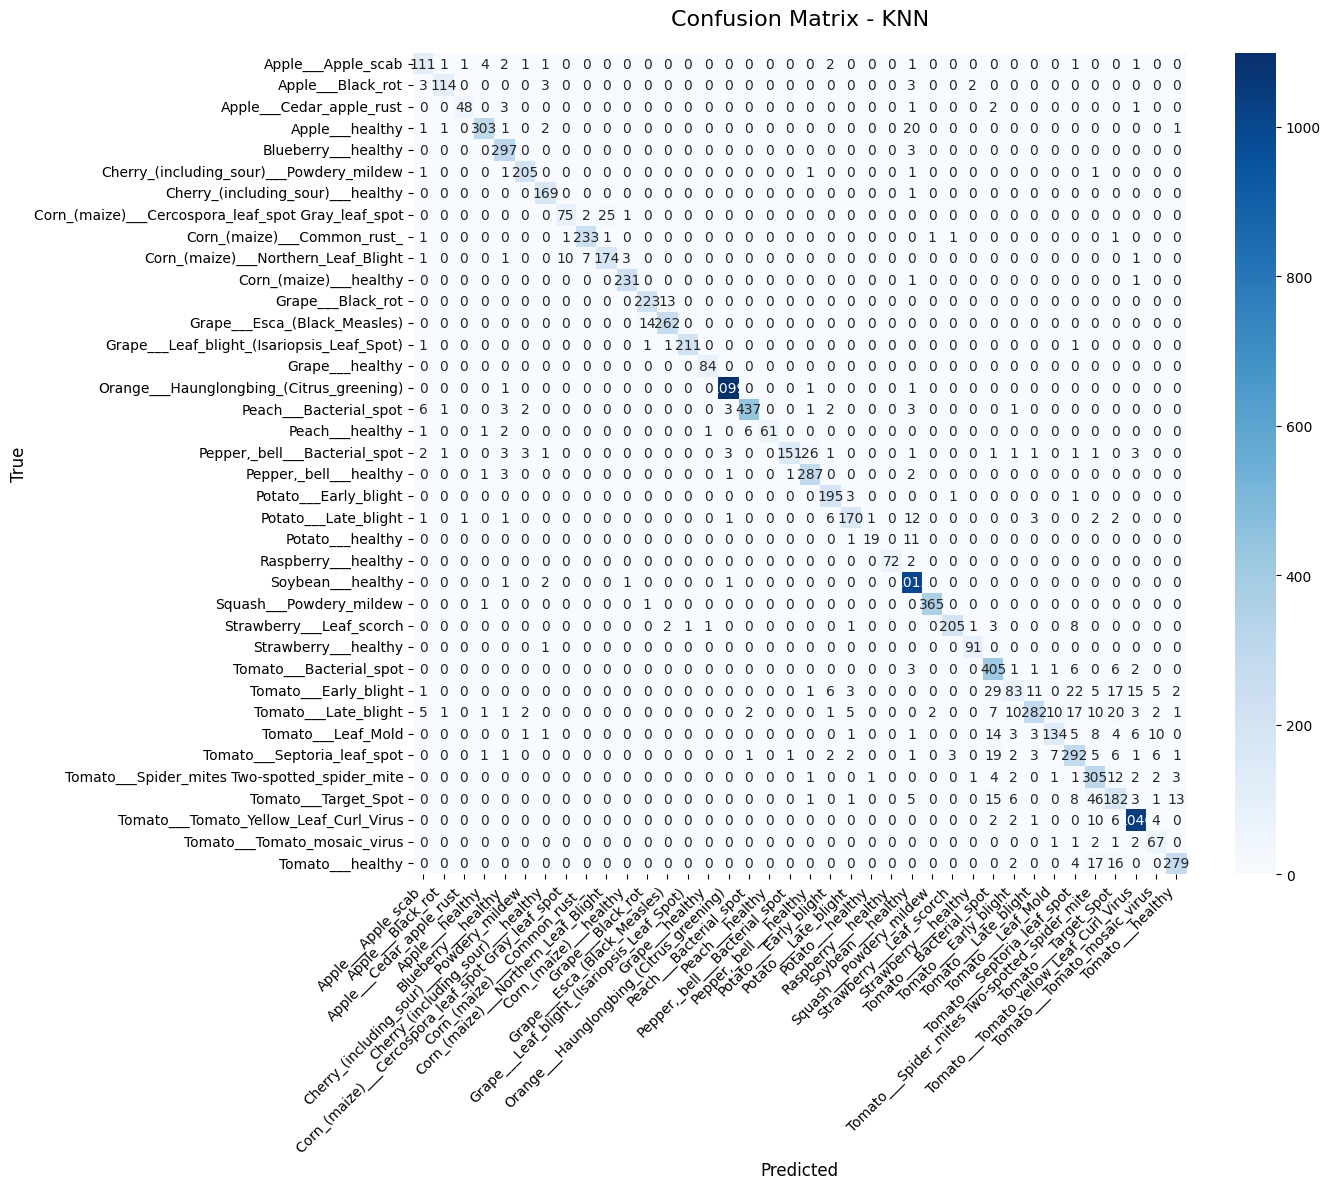

In [11]:
cm_knn = confusion_matrix(y_val, knn_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - KNN', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Confusion Matrix - SVM

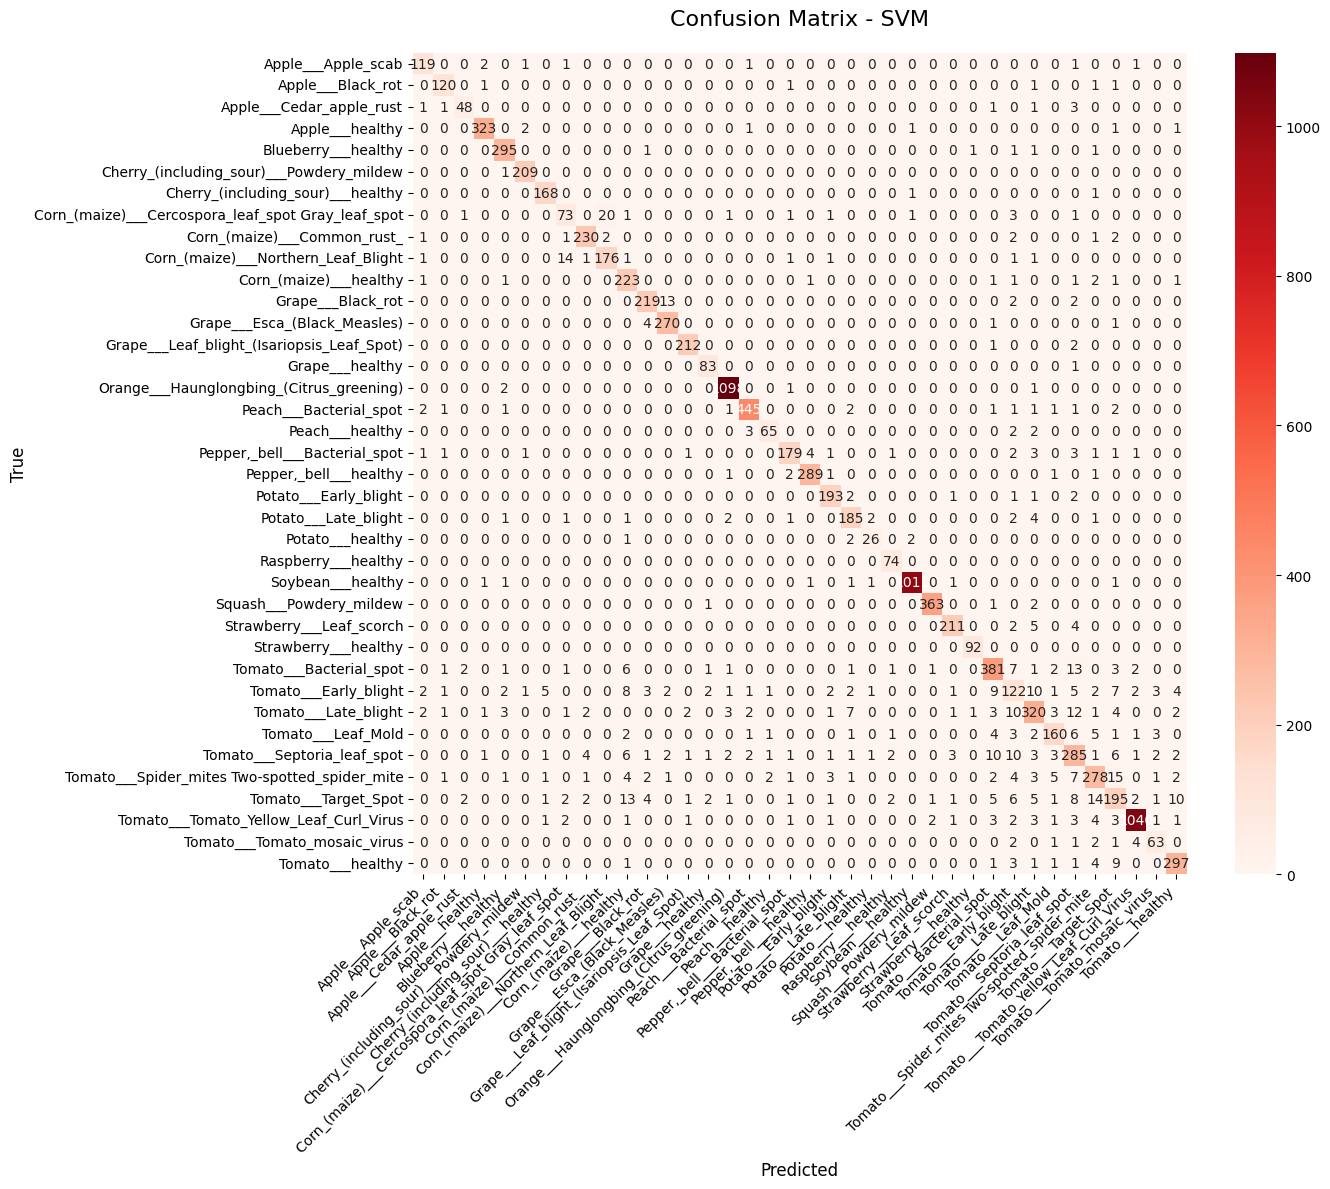

In [12]:
cm_svm = confusion_matrix(y_val, svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - SVM', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. So sánh Hiệu suất

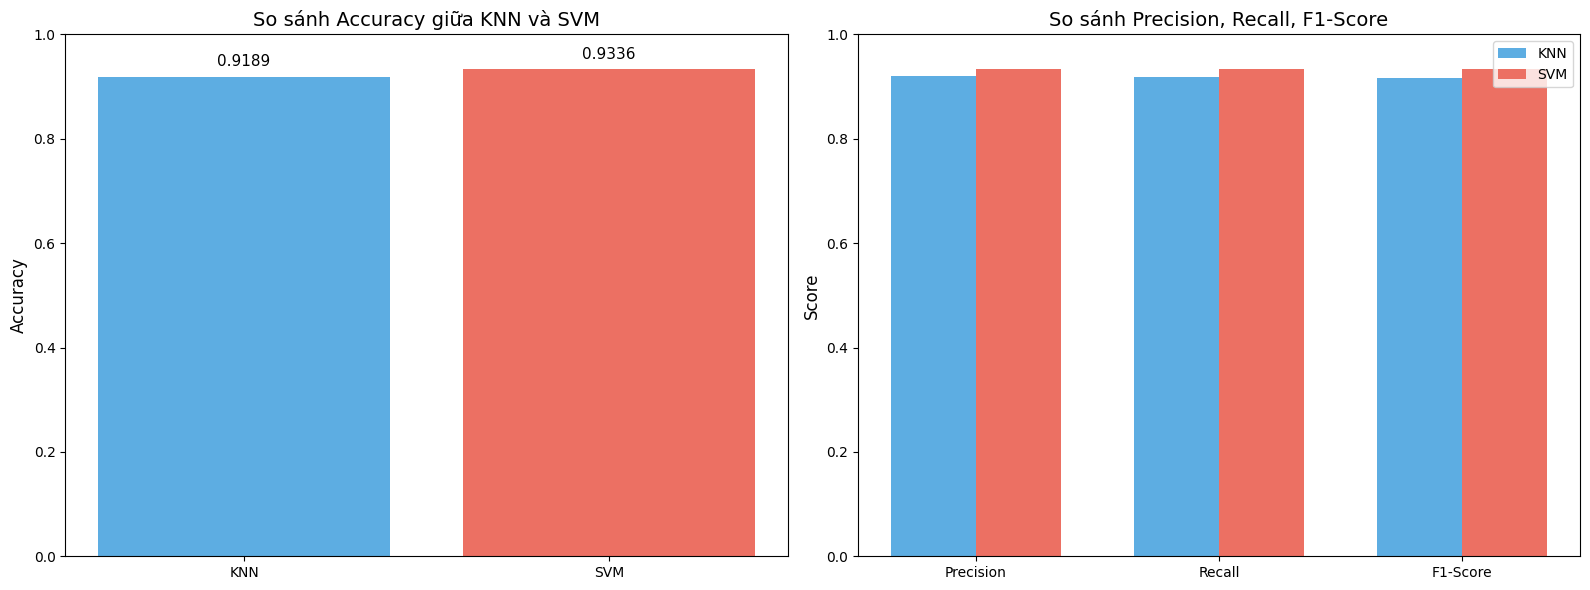

In [13]:
# Tính metrics
knn_p, knn_r, knn_f1, _ = precision_recall_fscore_support(y_val, knn_pred, average='weighted')
svm_p, svm_r, svm_f1, _ = precision_recall_fscore_support(y_val, svm_pred, average='weighted')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. So sánh Accuracy
axes[0].bar(['KNN', 'SVM'], [knn_acc, svm_acc], color=['#5DADE2', '#EC7063'])
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('So sánh Accuracy giữa KNN và SVM', fontsize=14)
axes[0].set_ylim([0, 1])
for i, v in enumerate([knn_acc, svm_acc]):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11)

# 2. So sánh Precision, Recall, F1-Score
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, [knn_p, knn_r, knn_f1], width, label='KNN', color='#5DADE2')
axes[1].bar(x + width/2, [svm_p, svm_r, svm_f1], width, label='SVM', color='#EC7063')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('So sánh Precision, Recall, F1-Score', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 14. So sánh Thời gian (QUAN TRỌNG!)

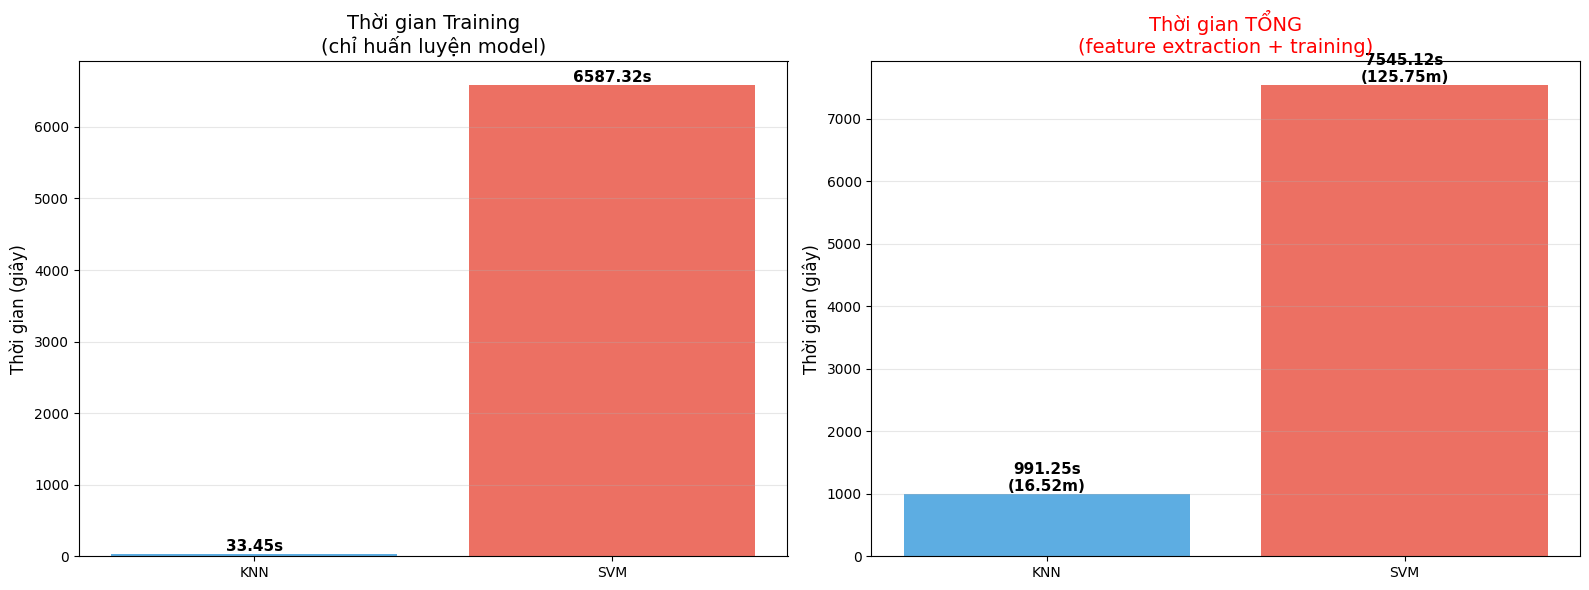


GIẢI THÍCH:
- Biểu đồ BÊN TRÁI: Chỉ thời gian training (10% tổng thời gian)
- Biểu đồ BÊN PHẢI: Thời gian thực tế (100% - bao gồm feature extraction)
- Feature extraction chiếm 12.6% thời gian!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Thời gian Training only (như biểu đồ cũ)
bars1 = axes[0].bar(['KNN', 'SVM'], [KNN_TIME, SVM_TIME], color=['#5DADE2', '#EC7063'])
axes[0].set_ylabel('Thời gian (giây)', fontsize=12)
axes[0].set_title('Thời gian Training\n(chỉ huấn luyện model)', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.2f}s',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Thời gian TỔNG (feature extraction + training) - CHÍNH XÁC!
knn_total = FEATURE_TIME + KNN_TIME
svm_total = FEATURE_TIME + SVM_TIME

bars2 = axes[1].bar(['KNN', 'SVM'], [knn_total, svm_total], color=['#5DADE2', '#EC7063'])
axes[1].set_ylabel('Thời gian (giây)', fontsize=12)
axes[1].set_title('Thời gian TỔNG\n(feature extraction + training)', fontsize=14, color='red')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.2f}s\n({h/60:.2f}m)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nGIẢI THÍCH:")
print("- Biểu đồ BÊN TRÁI: Chỉ thời gian training (10% tổng thời gian)")
print("- Biểu đồ BÊN PHẢI: Thời gian thực tế (100% - bao gồm feature extraction)")
print(f"- Feature extraction chiếm {FEATURE_TIME/TOTAL_TIME*100:.1f}% thời gian!")

## 15. Tổng kết

In [15]:
print("\n" + "="*60)
print("="*60)
print(f"\nKẾT QUẢ:")
print(f"\nKNN:")
print(f"  - Accuracy: {knn_acc:.4f}")
print(f"  - Precision: {knn_p:.4f}")
print(f"  - Recall: {knn_r:.4f}")
print(f"  - F1-Score: {knn_f1:.4f}")
print(f"\nSVM:")
print(f"  - Accuracy: {svm_acc:.4f}")
print(f"  - Precision: {svm_p:.4f}")
print(f"  - Recall: {svm_r:.4f}")
print(f"  - F1-Score: {svm_f1:.4f}")
print("="*60)



KẾT QUẢ:

KNN:
  - Accuracy: 0.9189
  - Precision: 0.9202
  - Recall: 0.9189
  - F1-Score: 0.9168

SVM:
  - Accuracy: 0.9336
  - Precision: 0.9331
  - Recall: 0.9336
  - F1-Score: 0.9331
